# InCommodities Case Crunch 2026 - Feature Engineering Validation
This notebook visualizes and structurally validates the stateless feature engineering functions built in `src/features.py` to ensure mathematical accuracy and absence of lookahead bias prior to model training.

### Task 1: Setup & Ingestion
Load data using `load_competition_data()`. The underlying function automatically performs the causal forward-fill for sparse daily variables based on `config.yaml`.

**Physical Grid Constants & Sources:**
* **FR Nuclear Capacity (61,400 MW):** France operates 56 reactors with a total installed capacity of roughly 61.4 GW. (Source: RTE / World Nuclear Association).
* **UK Nuclear Capacity (5,800 MW):** The UK's active nuclear fleet capacity is roughly 5.8 GW. (Source: National Grid ESO / World Nuclear Association).
* **CCGT Efficiency (50%):** A modern Combined Cycle Gas Turbine has an average thermal efficiency of 50%, meaning it requires 2 MWh of gas to produce 1 MWh of electricity.
* **Emission Factor (0.202 tCO2/MWh):** Burning natural gas emits approximately 0.202 tonnes of CO2 per MWh of thermal energy.

In [28]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.feature_selection import mutual_info_regression

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

sys.path.append(os.path.abspath('..'))
from src.data_ingestion import load_competition_data
from src.features import apply_full_feature_engineering

print("Loading dataset...")
df = load_competition_data(config_path="../config.yaml")
print("Applying full feature engineering...")
df = apply_full_feature_engineering(df)
print(f"Final Engineered shape: {df.shape}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading dataset...
Applying full feature engineering...
Final Engineered shape: (17544, 145)


### Task 2: Visualizing Residual Load
Validating `ResLoad = load_f - (solar_f + wind_f)` for France.

Residual Load Describe (France):
count    17544.000000
mean     41612.677595
std      10413.957012
min      14523.330000
25%      34424.472500
50%      39635.565000
75%      46352.985000
max      78562.830000
Name: fr_res_load, dtype: float64

If min >= 0, our math is solid.


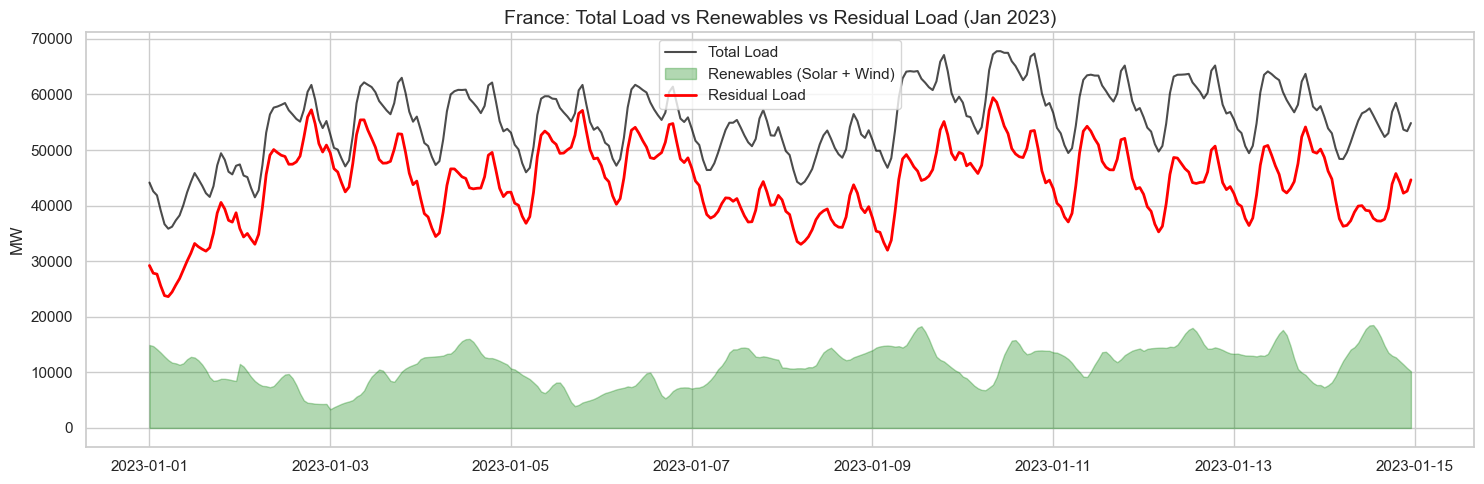

In [29]:
print("Residual Load Describe (France):")
print(df['fr_res_load'].describe())
print("\nIf min >= 0, our math is solid.")
# 2-Week Slice: January 2023
slice_2w = df.loc['2023-01-01':'2023-01-14']
plt.figure(figsize=(15, 5))
plt.plot(slice_2w.index, slice_2w['fr_load_f'], label='Total Load', color='black', alpha=0.7)
plt.fill_between(slice_2w.index, 0, slice_2w['fr_solar_f'] + slice_2w['fr_wind_f'], 
                 label='Renewables (Solar + Wind)', color='green', alpha=0.3)
plt.plot(slice_2w.index, slice_2w['fr_res_load'], label='Residual Load', color='red', linewidth=2)
plt.title('France: Total Load vs Renewables vs Residual Load (Jan 2023)', fontsize=14)
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

### Task 3: Visualizing the Thermal Floor
Validating the proxy marginal cost: `Cost_Thermal = (gas_price / 0.5) + (emission_price * 0.202 / 0.5)`.

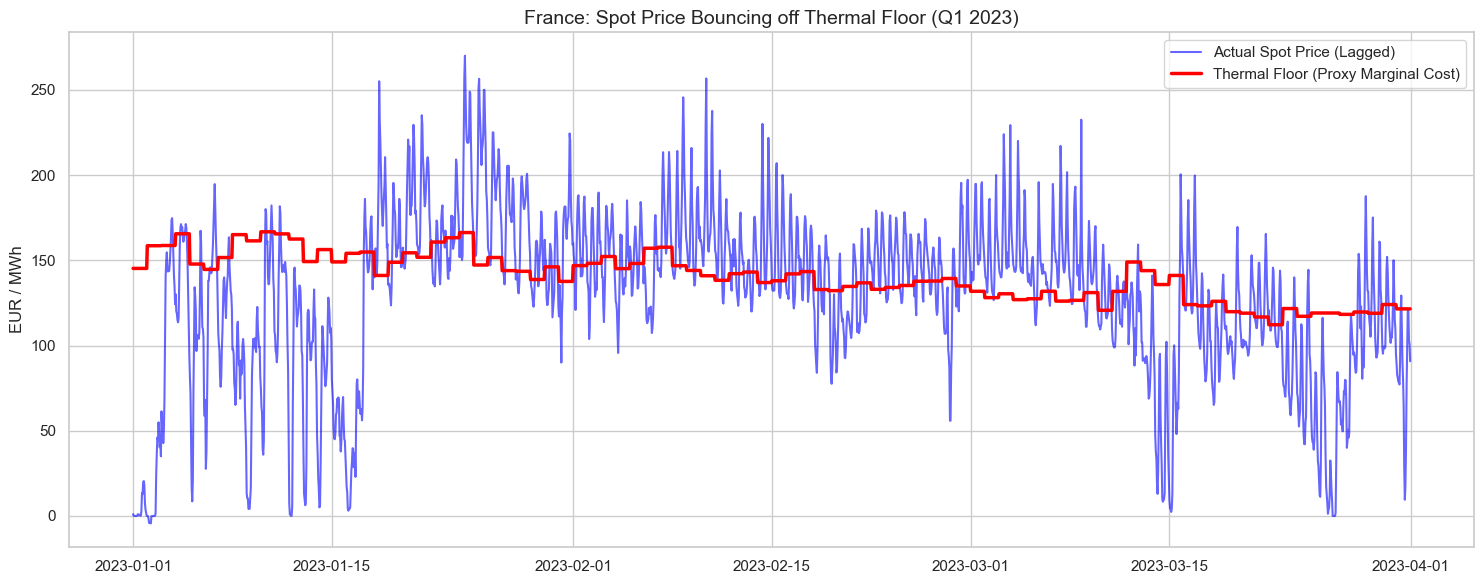

In [30]:
# 3-Month Slice: Jan - Mar 2023
slice_3m = df.loc['2023-01-01':'2023-03-31']
plt.figure(figsize=(15, 6))
plt.plot(slice_3m.index, slice_3m['fr_spot_la'], label='Actual Spot Price (Lagged)', color='blue', alpha=0.6)
plt.plot(slice_3m.index, slice_3m['fr_thermal_floor'], label='Thermal Floor (Proxy Marginal Cost)', color='red', linewidth=2.5)
plt.title('France: Spot Price Bouncing off Thermal Floor (Q1 2023)', fontsize=14)
plt.ylabel('EUR / MWh')
plt.legend()
plt.tight_layout()
plt.show()

### Task 4: Visualizing Interconnector Congestion (Viking Link)
Validating `ATC_Ratio` and the boolean online mask handling missing rows.

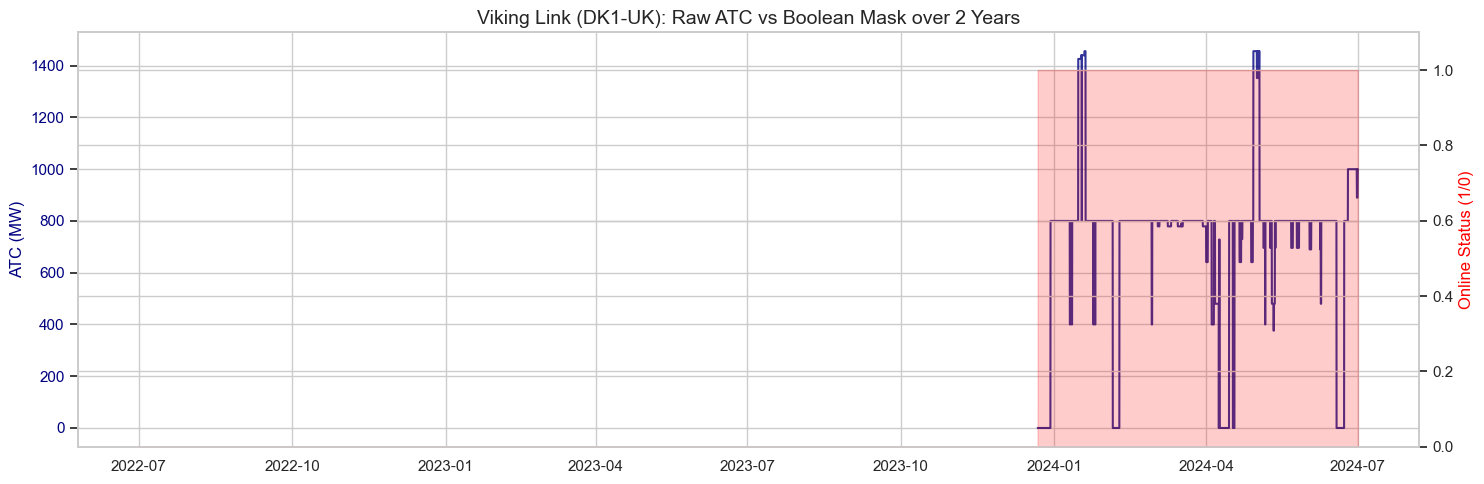

In [31]:
fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(df.index, df['atc_dk1-uk_f'], color='navy', label='Raw ATC (Viking Link)', alpha=0.8)
ax1.set_ylabel('ATC (MW)', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')
ax2 = ax1.twinx()
ax2.fill_between(df.index, 0, df['is_atc_dk1-uk_f_online'], color='red', alpha=0.2, label='is_online Mask')
ax2.set_ylabel('Online Status (1/0)', color='red')
ax2.set_ylim(0, 1.1)
plt.title('Viking Link (DK1-UK): Raw ATC vs Boolean Mask over 2 Years', fontsize=14)
fig.tight_layout()
plt.show()

### Task 5: Visualizing Calendar & Weekly Periodicity
Proving the weekend price drop and the strong 168-hour lag correlation.

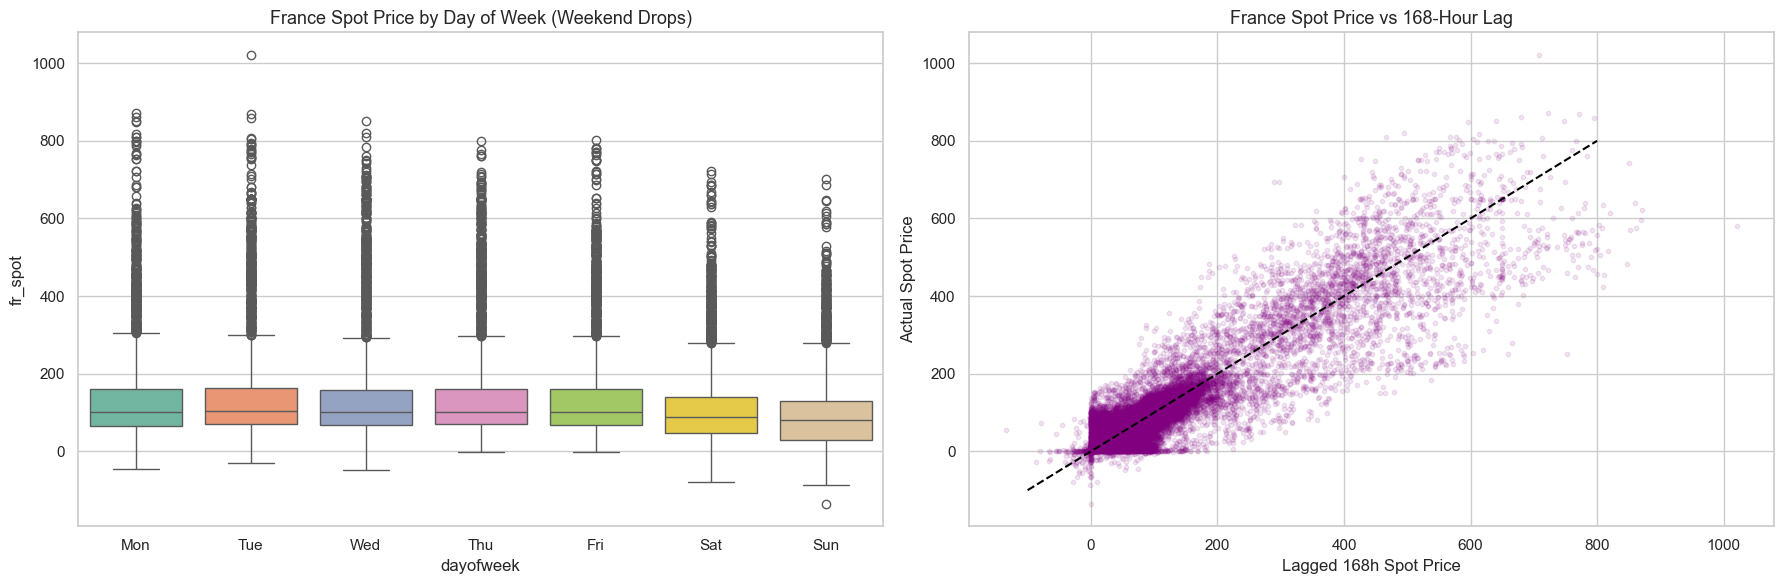

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
# Boxplot by Day of Week (0=Monday, 6=Sunday)
sns.boxplot(ax=axes[0], data=df, x='dayofweek', y='fr_spot', palette='Set2')
axes[0].set_title('France Spot Price by Day of Week (Weekend Drops)', fontsize=13)
axes[0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
# Scatter: Actual vs 168h Lag
axes[1].scatter(df['fr_spot_la_lag_168'], df['fr_spot'], alpha=0.1, color='purple', s=10)
axes[1].plot([-100, 800], [-100, 800], color='black', linestyle='--') # Identity line
axes[1].set_title('France Spot Price vs 168-Hour Lag', fontsize=13)
axes[1].set_xlabel('Lagged 168h Spot Price')
axes[1].set_ylabel('Actual Spot Price')
plt.tight_layout()
plt.show()

### Task 6: Visualizing Nuclear Shortfall & Volatility
Aligning extreme price behavior with nuclear capacity deficits.

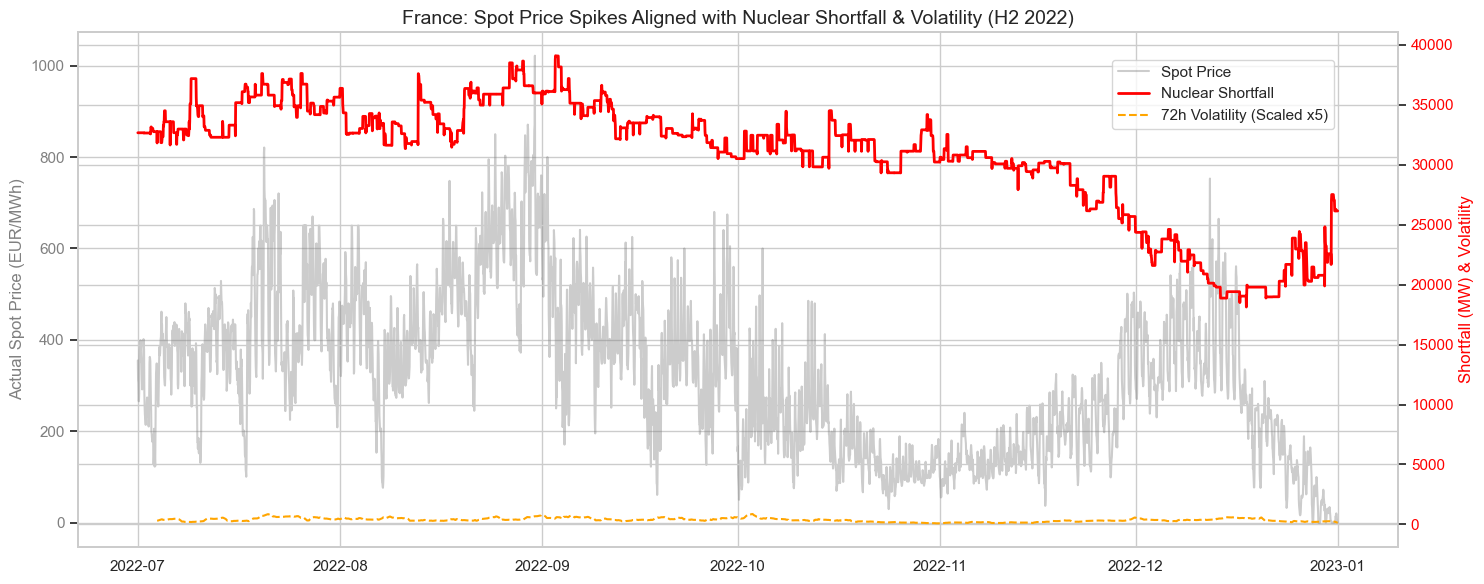

In [33]:
slice_6m = df.loc['2022-07-01':'2022-12-31'] # Winter 2022 stress
fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(slice_6m.index, slice_6m['fr_spot'], color='gray', alpha=0.4, label='Spot Price')
ax1.set_ylabel('Actual Spot Price (EUR/MWh)', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')
ax2 = ax1.twinx()
ax2.plot(slice_6m.index, slice_6m['fr_nuclear_shortfall'], color='red', linewidth=2, label='Nuclear Shortfall')
ax2.plot(slice_6m.index, slice_6m['fr_spot_la_vol_72h'] * 5, color='orange', linestyle='--', label='72h Volatility (Scaled x5)')
ax2.set_ylabel('Shortfall (MW) & Volatility', color='red')
ax2.tick_params(axis='y', labelcolor='red')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.title('France: Spot Price Spikes Aligned with Nuclear Shortfall & Volatility (H2 2022)', fontsize=14)
fig.tight_layout()
plt.show()

### Task 5: Visualizing Heavy-Tail Compression (asinh)
Validating how `np.arcsinh()` smoothly compresses the right-tail kurtosis while preserving negative price structures for UK spot prices.

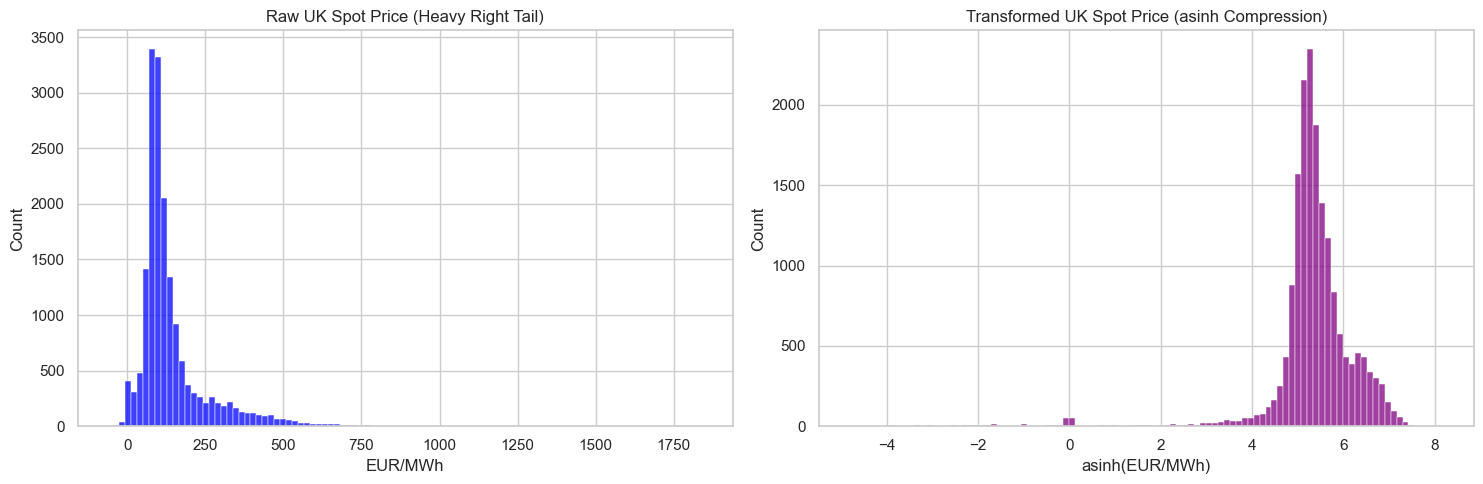

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['uk_spot_la'].dropna(), bins=100, ax=axes[0], color='blue')
axes[0].set_title('Raw UK Spot Price (Heavy Right Tail)')
axes[0].set_xlabel('EUR/MWh')
sns.histplot(df['uk_spot_la_asinh'].dropna(), bins=100, ax=axes[1], color='purple')
axes[1].set_title('Transformed UK Spot Price (asinh Compression)')
axes[1].set_xlabel('asinh(EUR/MWh)')
plt.tight_layout()
plt.show()


### Task 6: Visualizing the 3-Hour Residual Ramps
Comparing a 1-week winter slice (January 2023) of France's absolute residual load vs the engineered 3-hour ramp metric.

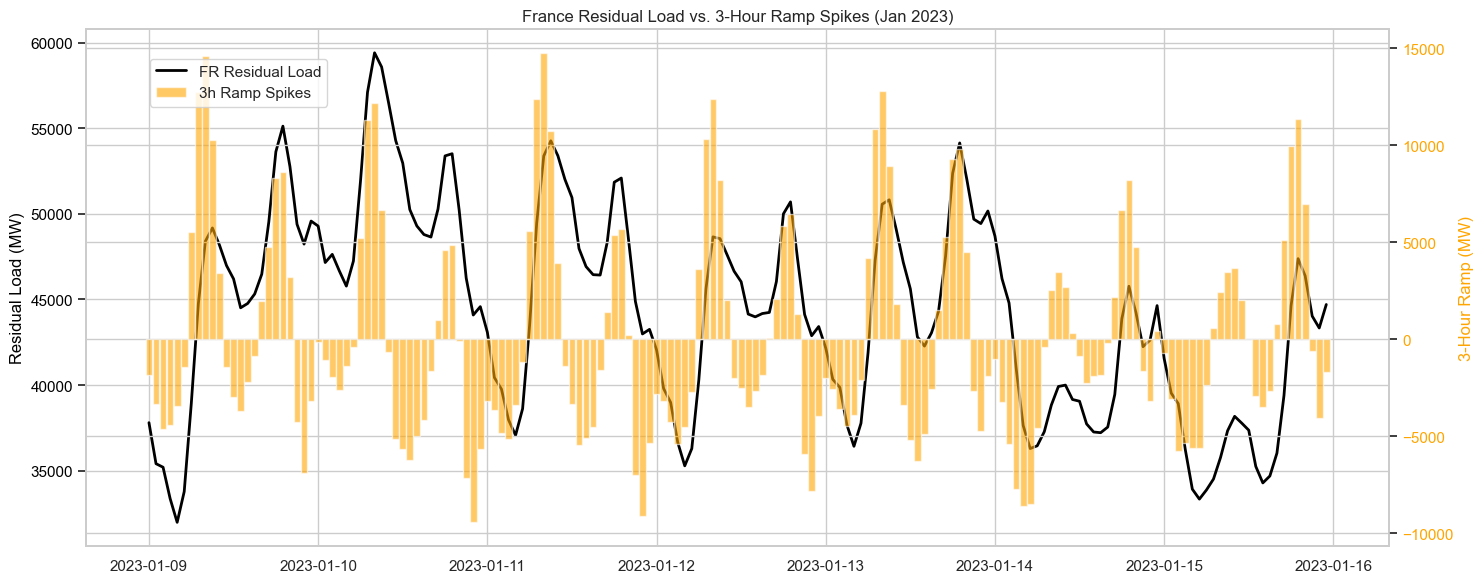

In [35]:
start_dt = '2023-01-09'
end_dt = '2023-01-15'
df_slice = df.loc[start_dt:end_dt]
fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(df_slice.index, df_slice['fr_res_load'], color='black', linewidth=2, label='FR Residual Load')
ax1.set_ylabel('Residual Load (MW)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax2 = ax1.twinx()
ax2.bar(df_slice.index, df_slice['fr_res_load_ramp_3h'], color='orange', alpha=0.6, width=0.04, label='3h Ramp Spikes')
ax2.set_ylabel('3-Hour Ramp (MW)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
plt.title('France Residual Load vs. 3-Hour Ramp Spikes (Jan 2023)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.9))
plt.tight_layout()
plt.show()


### Task 7: Visualizing Scarcity & Security Margins
Dual-axis tracking of France's Security Margin against the realized spot price over a two-month winter period, highlighting extreme price convexity near zero capacity.

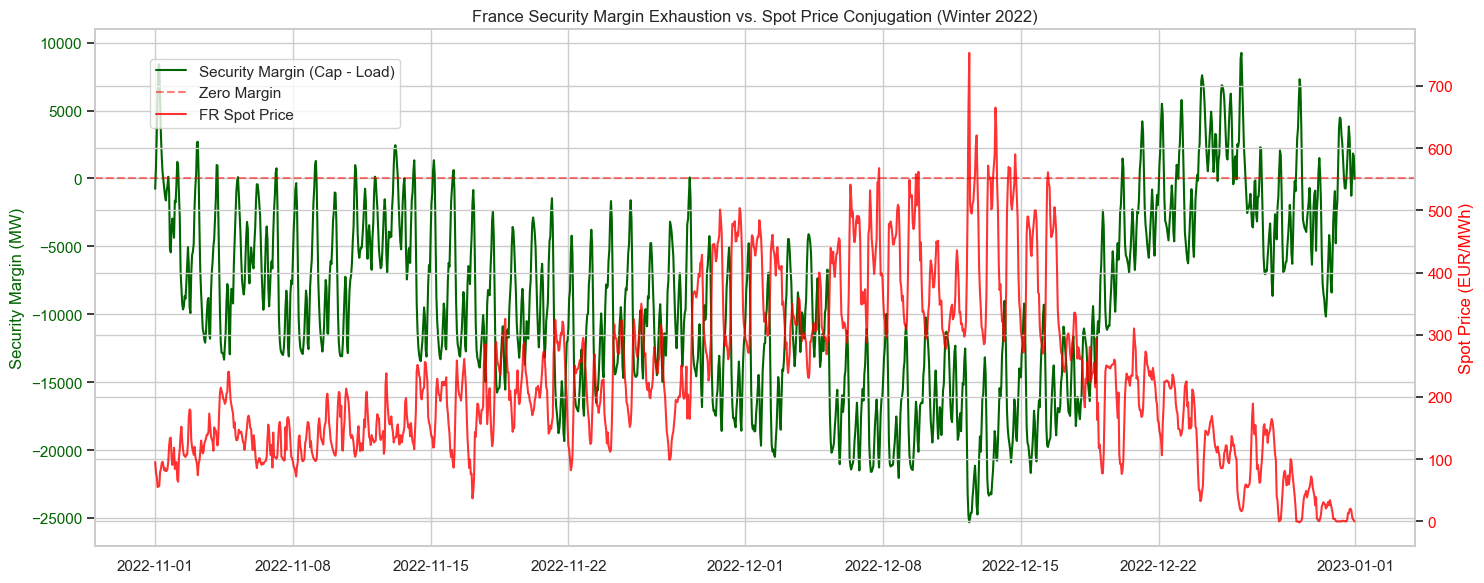

In [36]:
start_dt = '2022-11-01'
end_dt = '2022-12-31'
df_slice = df.loc[start_dt:end_dt]
fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(df_slice.index, df_slice['fr_security_margin'], color='darkgreen', linewidth=1.5, label='Security Margin (Cap - Load)')
ax1.set_ylabel('Security Margin (MW)', color='darkgreen')
ax1.tick_params(axis='y', labelcolor='darkgreen')
ax1.axhline(0, color='red', linestyle='--', alpha=0.5, label='Zero Margin')
ax2 = ax1.twinx()
ax2.plot(df_slice.index, df_slice['fr_spot'], color='red', alpha=0.8, linewidth=1.5, label='FR Spot Price')
ax2.set_ylabel('Spot Price (EUR/MWh)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
plt.title('France Security Margin Exhaustion vs. Spot Price Conjugation (Winter 2022)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.9))
plt.tight_layout()
plt.show()


### Task 8: Visualizing 14-Day Rolling Z-Scores
Assessing how structured rolling Z-scores normalize the underlying seasonal load increase, spanning from Summer (July) into early Winter (December).

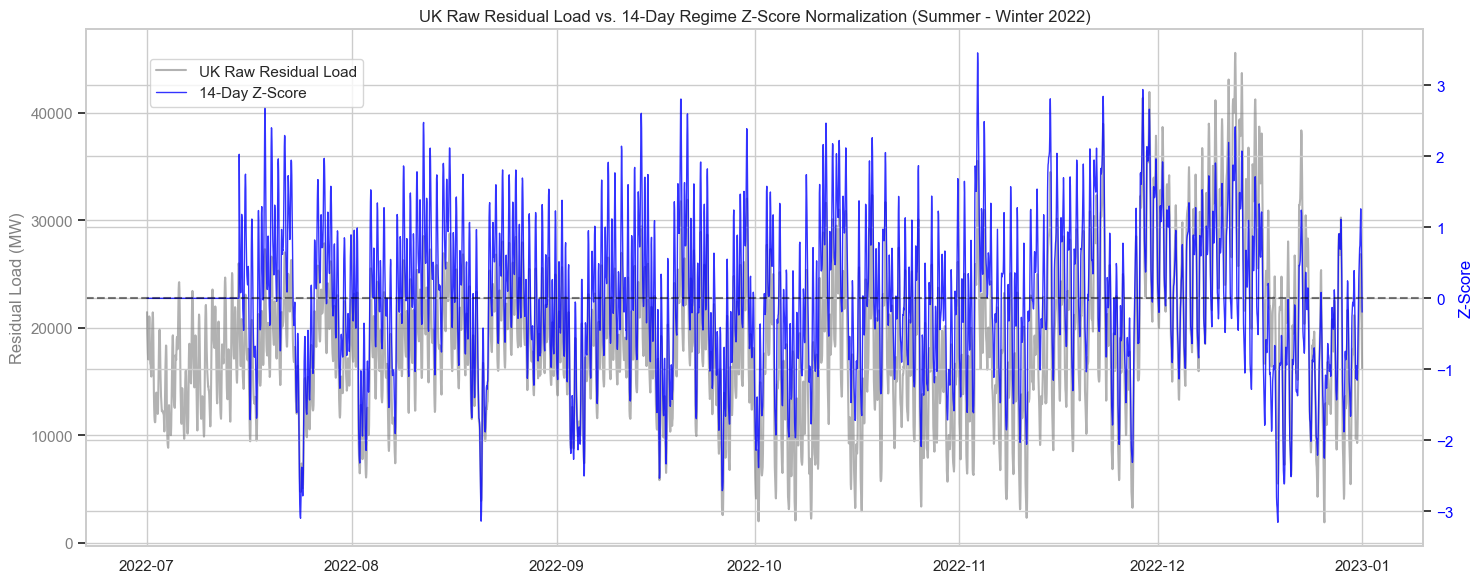

In [37]:
start_dt = '2022-07-01'
end_dt = '2022-12-31'
df_slice = df.loc[start_dt:end_dt]
fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(df_slice.index, df_slice['uk_res_load'], color='grey', alpha=0.6, label='UK Raw Residual Load')
ax1.set_ylabel('Residual Load (MW)', color='grey')
ax1.tick_params(axis='y', labelcolor='grey')
ax2 = ax1.twinx()
ax2.plot(df_slice.index, df_slice['uk_res_load_zscore_14d'], color='blue', linewidth=1, alpha=0.8, label='14-Day Z-Score')
ax2.set_ylabel('Z-Score', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('UK Raw Residual Load vs. 14-Day Regime Z-Score Normalization (Summer - Winter 2022)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.9))
plt.tight_layout()
plt.show()


### Task 2: Visualizing Target Stationarity (The INCOMO 3 Approach)
This visualizes the target stationarity validation to see if the rolling mean absorbs regime shifts.

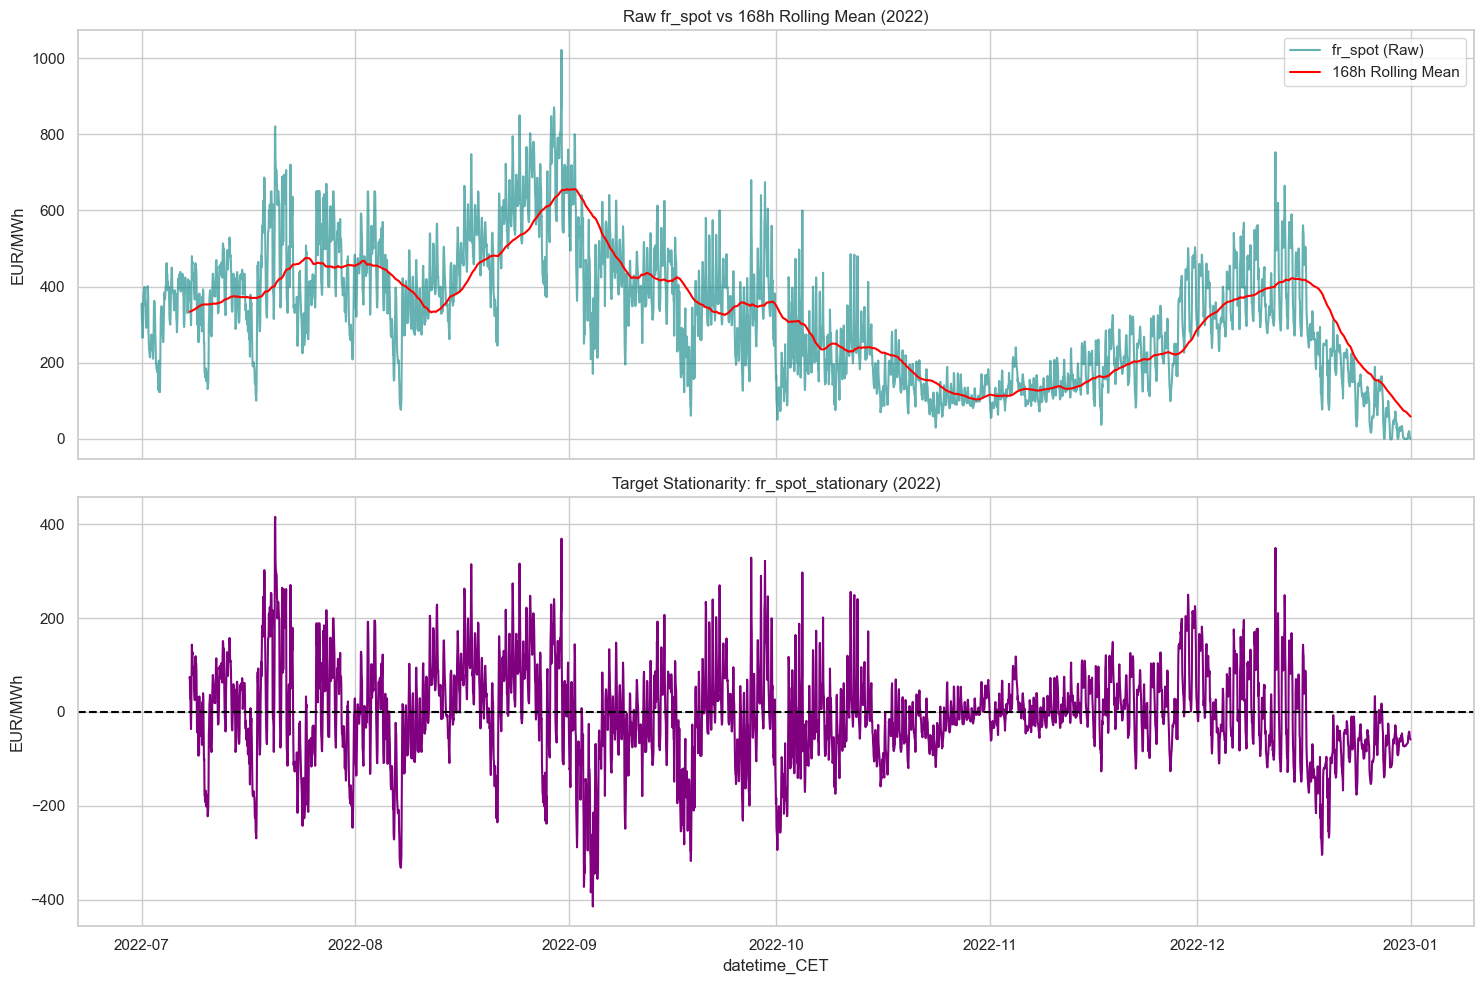

Raw fr_spot Std Dev: 141.62
Stationary fr_spot Std Dev: 58.79
Variance reduction: 82.77%


In [38]:
# 1. Calculate 'fr_spot_la_roll_168h_mean' (7-day rolling mean) on the raw dataframe
df['fr_spot_la_roll_168h_mean'] = df['fr_spot'].rolling(window=168).mean()

# 2. Calculate the deviation: 'fr_spot_stationary' = fr_spot - fr_spot_la_roll_168h_mean
df['fr_spot_stationary'] = df['fr_spot'] - df['fr_spot_la_roll_168h_mean']

# 3. Create a 2-panel subplot (2 rows, 1 column) spanning the year 2022
import matplotlib.pyplot as plt
import seaborn as sns

# Reset index to avoid ValueError when plotting with duplicate datetime indices (e.g. DST transitions)
df_2022 = df.loc['2022'].reset_index()
x_col = df_2022.columns[0]  # Gets the datetime column name, usually 'datetime_CET'

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Top panel: Plot the raw 'fr_spot' and overlay the 'fr_spot_la_roll_168h_mean' in red
sns.lineplot(data=df_2022, x=x_col, y='fr_spot', ax=axes[0], label='fr_spot (Raw)', color='teal', alpha=0.6)
sns.lineplot(data=df_2022, x=x_col, y='fr_spot_la_roll_168h_mean', ax=axes[0], label='168h Rolling Mean', color='red')
axes[0].set_title('Raw fr_spot vs 168h Rolling Mean (2022)')
axes[0].set_ylabel('EUR/MWh')

# Bottom panel: Plot the 'fr_spot_stationary' residual. Add a horizontal dashed line at y=0.
sns.lineplot(data=df_2022, x=x_col, y='fr_spot_stationary', ax=axes[1], color='purple')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Target Stationarity: fr_spot_stationary (2022)')
axes[1].set_ylabel('EUR/MWh')

plt.tight_layout()
plt.show()

# 4. Add a print statement calculating the standard deviation of the raw 'fr_spot' vs the 'fr_spot_stationary'
raw_std = df['fr_spot'].std()
stat_std = df['fr_spot_stationary'].std()
print(f"Raw fr_spot Std Dev: {raw_std:.2f}")
print(f"Stationary fr_spot Std Dev: {stat_std:.2f}")
print(f"Variance reduction: {100 * (1 - (stat_std**2 / raw_std**2)):.2f}%")


### Task 3: Visualizing Merit Order & Scarcity
Exploring the 'euro_scarcity_ratio' to validate the non-linear Merit Order convexity (when scarcity approaches 1.0).

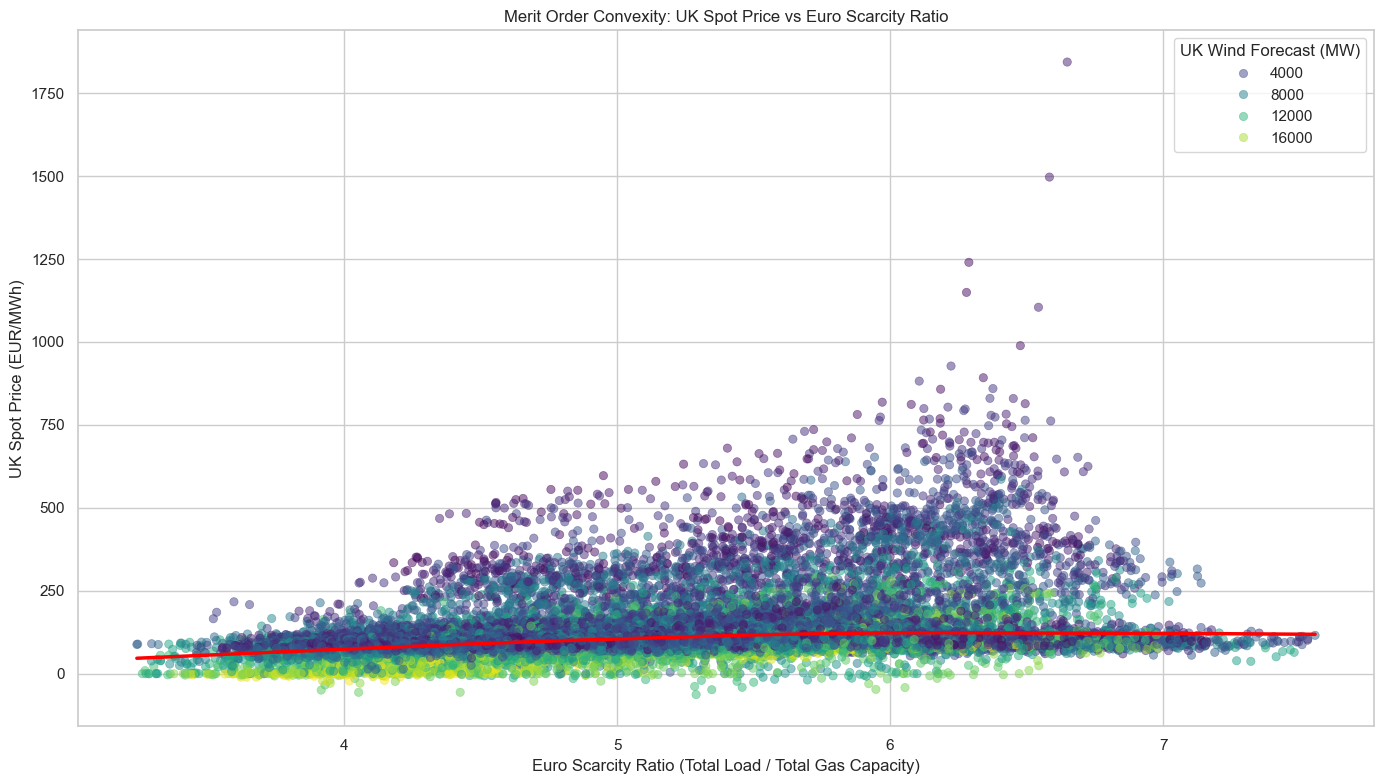

In [39]:
# 1. Calculate 'euro_scarcity_ratio' using load and gas capacity proxies across Europe
load_cols = [c for c in df.columns if 'load_f' in c]
gas_cap_cols = [c for c in df.columns if 'gas_avcap_f' in c]

euro_load = df[load_cols].sum(axis=1)
euro_gas_cap = df[gas_cap_cols].sum(axis=1)

import numpy as np
df['euro_scarcity_ratio'] = euro_load / euro_gas_cap.replace(0, np.nan)

# 2. & 3. Create a scatter plot with hue and a lowess trendline
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

# Drop NAs specifically for the LOWESS trendline to avoid statsmodels errors
plot_df = df[['euro_scarcity_ratio', 'uk_spot', 'uk_wind_f']].dropna()

# Scatter plot colored by UK wind
sns.scatterplot(
    data=plot_df, 
    x='euro_scarcity_ratio', 
    y='uk_spot', 
    hue='uk_wind_f', 
    palette='viridis', 
    alpha=0.5,
    edgecolor=None
)

# LOWESS trendline to visualize Merit Order convexity
sns.regplot(
    data=plot_df, 
    x='euro_scarcity_ratio', 
    y='uk_spot', 
    scatter=False, 
    lowess=True, 
    color='red', 
    line_kws={'linewidth': 2.5, 'label': 'LOWESS Trend (Convexity)'}
)

plt.title('Merit Order Convexity: UK Spot Price vs Euro Scarcity Ratio')
plt.xlabel('Euro Scarcity Ratio (Total Load / Total Gas Capacity)')
plt.ylabel('UK Spot Price (EUR/MWh)')
plt.legend(title='UK Wind Forecast (MW)')
plt.tight_layout()
plt.show()


### Task 4: Rapid Feature Evaluation & SHAP Analysis
Leveraging LightGBM on a 6-month holdout evaluation set to generate SHAP metrics and systematically identify features with weak predictive power for pruning.

--- FRANCE: fr_spot_stationary ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002241 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 21618
[LightGBM] [Info] Number of data points in the train set: 4392, number of used features: 117
[LightGBM] [Info] Start training from score 0.086656
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

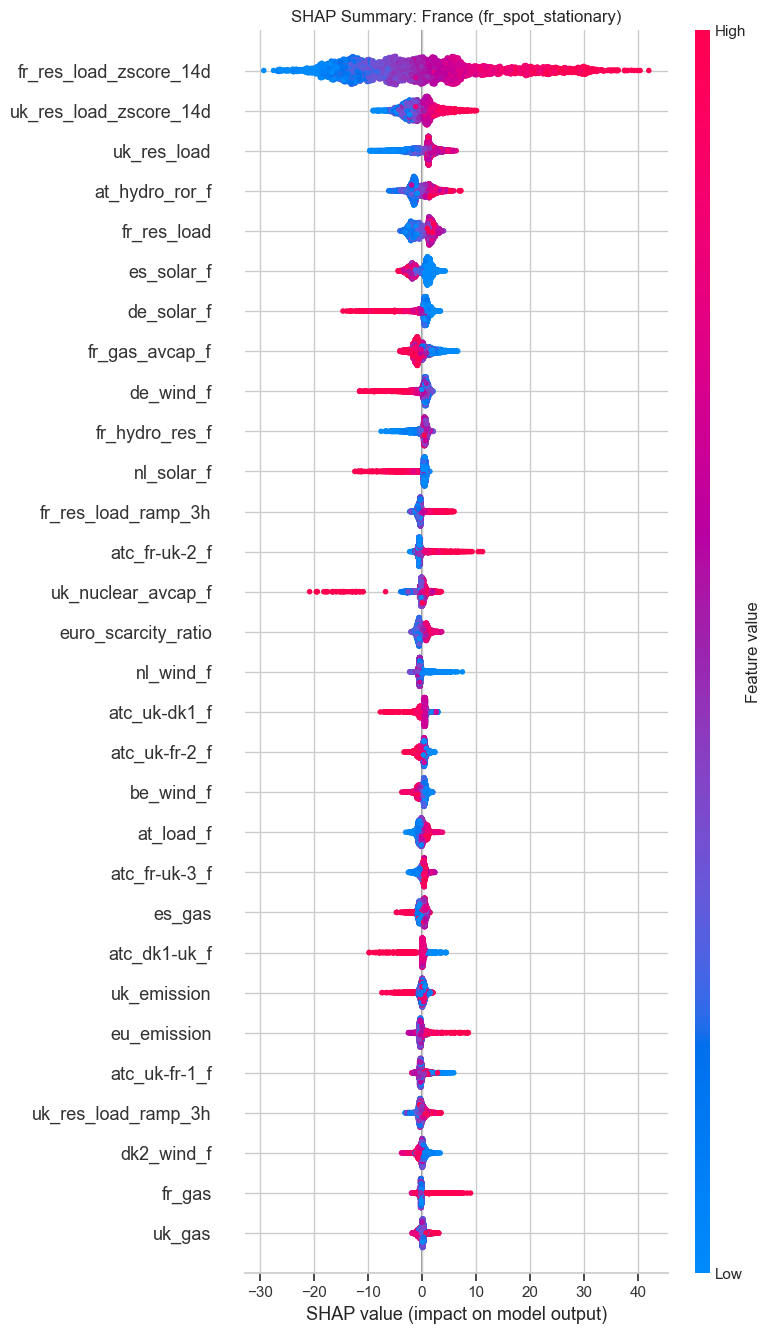

France Features to DROP (mean SHAP < 0.05): 34 features
['atc_uk-be_f', 'atc_uk-fr-3_f', 'ntc_be-uk_f', 'ntc_dk1-uk_f', 'ntc_fr-uk-1_f', 'ntc_fr-uk-2_f', 'ntc_fr-uk-3_f', 'ntc_nl-uk_f', 'ntc_uk-be_f', 'ntc_uk-dk1_f', 'ntc_uk-fr-1_f', 'ntc_uk-fr-2_f', 'ntc_uk-fr-3_f', 'ntc_uk-nl_f', 'cost_uk-fr-1_la', 'cost_uk-fr-3_la', 'flow_fr-uk-1_la', 'flow_fr-uk-2_la', 'flow_nl-uk_la', 'flow_uk-be_la', 'flow_uk-fr-1_la', 'flow_uk-fr-2_la', 'flow_uk-fr-3_la', 'is_atc_dk1-uk_f_online', 'is_atc_nl-uk_f_online', 'is_atc_uk-dk1_f_online', 'is_atc_uk-nl_f_online', 'is_cost_dk1-uk_la_online', 'is_cost_fr-uk-2_la_online', 'is_cost_uk-dk1_la_online', 'is_cost_uk-fr-2_la_online', 'month', 'is_fr_holiday', 'uk_nuclear_shortfall']

--- UK: uk_spot_basis ---
'uk_spot_basis' not found in dataframe! Falling back to 'uk_spot'...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002281 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bi

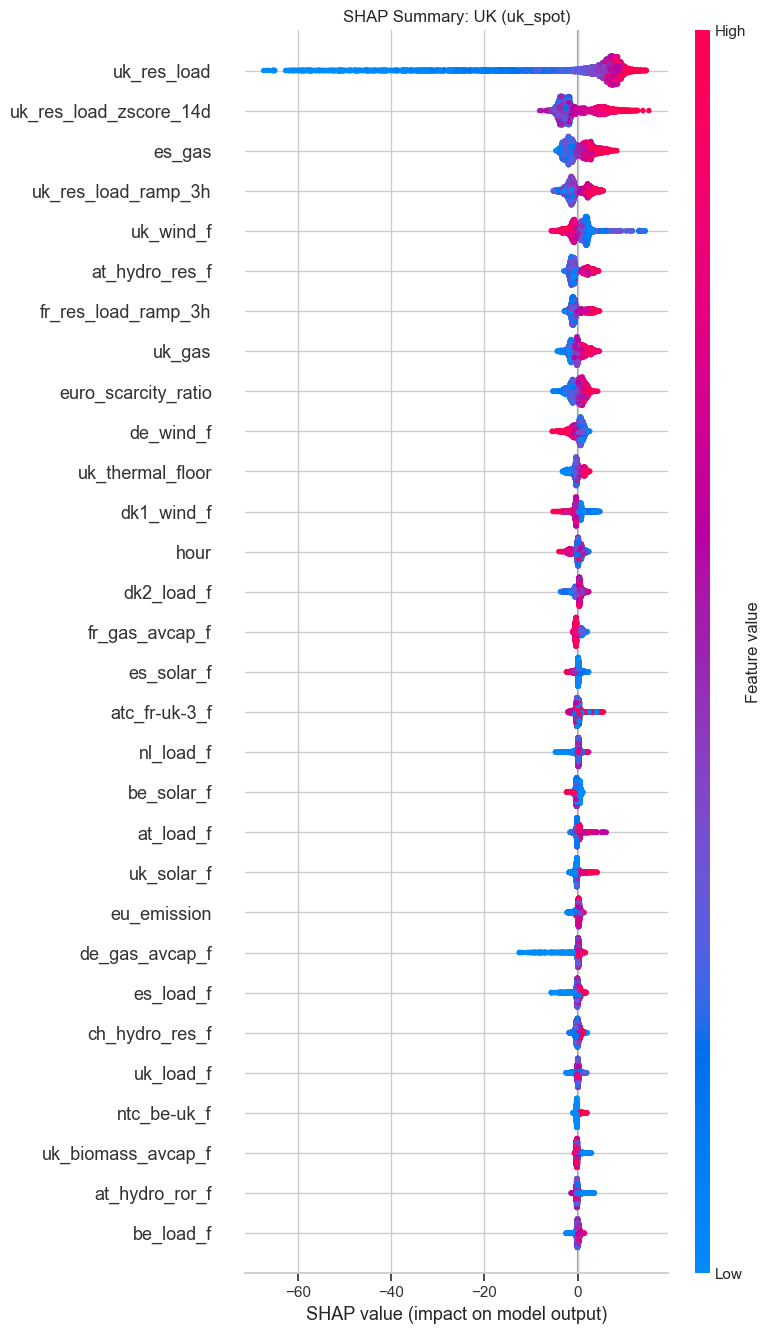

UK Features to DROP (mean SHAP < 0.05): 39 features
['fr_river_temp_rhine_rheinfelden_f', 'atc_uk-fr-3_f', 'atc_uk-nl_f', 'ntc_dk1-uk_f', 'ntc_fr-uk-1_f', 'ntc_fr-uk-2_f', 'ntc_fr-uk-3_f', 'ntc_nl-uk_f', 'ntc_uk-be_f', 'ntc_uk-dk1_f', 'ntc_uk-fr-1_f', 'ntc_uk-fr-2_f', 'ntc_uk-fr-3_f', 'ntc_uk-nl_f', 'cost_uk-dk1_la', 'cost_uk-fr-1_la', 'cost_uk-fr-2_la', 'flow_be-uk_la', 'flow_fr-uk-1_la', 'flow_fr-uk-2_la', 'flow_fr-uk-3_la', 'flow_nl-uk_la', 'flow_uk-be_la', 'flow_uk-dk1_la', 'flow_uk-fr-1_la', 'flow_uk-fr-2_la', 'flow_uk-fr-3_la', 'is_atc_dk1-uk_f_online', 'is_atc_nl-uk_f_online', 'is_atc_uk-dk1_f_online', 'is_atc_uk-nl_f_online', 'is_cost_dk1-uk_la_online', 'is_cost_fr-uk-2_la_online', 'is_cost_uk-dk1_la_online', 'is_cost_uk-fr-2_la_online', 'is_fr_holiday', 'is_uk_holiday', 'fr_nuclear_shortfall', 'uk_nuclear_shortfall']


In [41]:
import shap
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Select the last 6 months of the training data as a fast evaluation set
cutoff_date = df.index.max() - pd.DateOffset(months=6)
df_eval = df.loc[df.index >= cutoff_date]

# Determine features (exclude target and identifiers)
exclude_cols = [c for c in df_eval.columns if 'spot' in c or c == 'id']

print("--- FRANCE: fr_spot_stationary ---")
# 3. Drop rows with NaNs in the target
df_fr = df_eval.dropna(subset=['fr_spot_stationary'])
X_fr = df_fr.drop(columns=[c for c in exclude_cols if c in df_fr.columns])
y_fr = df_fr['fr_spot_stationary']

# 4. Define LGBM Regressor
model_fr = lgb.LGBMRegressor(n_estimators=150, max_depth=5, learning_rate=0.1, random_state=42)

# 5. Fit the model
model_fr.fit(X_fr, y_fr)

# 6. Calculate SHAP values
explainer_fr = shap.TreeExplainer(model_fr)
shap_values_fr = explainer_fr.shap_values(X_fr)

# 7. Plot SHAP summary plot
plt.figure()
plt.title("SHAP Summary: France (fr_spot_stationary)")
shap.summary_plot(shap_values_fr, X_fr, max_display=30, show=False)
plt.show()

# 8. Extract absolute mean SHAP values per feature
mean_shap_fr = np.abs(shap_values_fr).mean(axis=0)
shap_df_fr = pd.DataFrame({'feature': X_fr.columns, 'mean_shap': mean_shap_fr})
drop_features_fr = shap_df_fr[shap_df_fr['mean_shap'] < 0.05]['feature'].tolist()
print(f"France Features to DROP (mean SHAP < 0.05): {len(drop_features_fr)} features")
print(drop_features_fr)


print("\n--- UK: uk_spot_basis ---")
target_uk = 'uk_spot_basis'
if target_uk not in df_eval.columns and 'uk_spot' in df_eval.columns:
    print(f"'{target_uk}' not found in dataframe! Falling back to 'uk_spot'...")
    target_uk = 'uk_spot'

df_uk = df_eval.dropna(subset=[target_uk])
X_uk = df_uk.drop(columns=[c for c in exclude_cols if c in df_uk.columns])
y_uk = df_uk[target_uk]

model_uk = lgb.LGBMRegressor(n_estimators=150, max_depth=5, learning_rate=0.1, random_state=42)
model_uk.fit(X_uk, y_uk)

explainer_uk = shap.TreeExplainer(model_uk)
shap_values_uk = explainer_uk.shap_values(X_uk)

plt.figure()
plt.title(f"SHAP Summary: UK ({target_uk})")
shap.summary_plot(shap_values_uk, X_uk, max_display=30, show=False)
plt.show()

mean_shap_uk = np.abs(shap_values_uk).mean(axis=0)
shap_df_uk = pd.DataFrame({'feature': X_uk.columns, 'mean_shap': mean_shap_uk})
drop_features_uk = shap_df_uk[shap_df_uk['mean_shap'] < 0.05]['feature'].tolist()
print(f"UK Features to DROP (mean SHAP < 0.05): {len(drop_features_uk)} features")
print(drop_features_uk)
